In [1]:
import sys
import numpy as np
import torch 
# still do preprocessing in scipy
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from importlib import reload
# get UMAP
import umap
from tqdm import tqdm
import pandas as pd

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')
import factor_model
reload(factor_model)

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='white', context='notebook', rc={'figure.figsize':(6,6)}, font_scale=1.5)

2.1.0.dev20230321+cu117
11.7
Tesla V100-PCIE-16GB
2.1.0.dev20230321+cu117
11.7
Tesla V100-PCIE-16GB


In [22]:
# Append this directory to sys.path
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/')
import Leaflet_load_cluster_data_03 as llc 

# Append also simulation directory
sys.path.append("/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/")
import Leaflet_simulate_counts as sim 
reload (sim)

<module 'Leaflet_simulate_counts' from '/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/Leaflet_simulate_counts.py'>

### Settings and Load Data 

In [3]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cuda


In [6]:
# let's simulate using the mammary gland data
input_files_folder = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/model_input/Mammary_Gland/"
#cell_types = ["Mammary_Gland_basal_cell", "Mammary_Gland_luminal_epithelial_cell_of_mammary_gland"]

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = llc.load_cluster_data(
    input_folder = input_files_folder, max_intron_count=5000, remove_singletons=True, has_genes="yes")  #, celltypes=cell_types)

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# get indices (maybe don't need this actually)
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/model_input/Mammary_Gland/
Finished reading in data from folder ...
Removing singletons ...
Number of junctions before removing singletons:  157665
Number of junctions after removing singletons:  47015
The number of unique cell types in the data is:  4
The number of unique cells in the data is:  2405
The number of unique junctions in the data is:  47016
The maximum junction count was initially:  251545
375
The maximum junction count is now:  4999
The number of junctions in the data is:  44087
The number of cells in the data is:  2405
The number of cell types in the data is:  4


In [7]:
cell_ids_conversion.cell_type.value_counts()

Mammary_Gland_basal_cell                                  1340
Mammary_Gland_luminal_epithelial_cell_of_mammary_gland     578
Mammary_Gland_stromal_cell                                 440
Mammary_Gland_endothelial_cell                              47
Name: cell_type, dtype: int64

In [8]:
# sanity check that counts are saved in correct indices in sparse matrices
ind_random = np.random.randint(0, len(final_data))
print(final_data.iloc[ind_random])
print(junc_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])
print(cluster_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])

cell_id_index                                                      579
junction_id_index                                                40157
junc_count                                                         0.0
cluster_count                                                       33
clustminjunc                                                      33.0
juncratio                                                          0.0
cell_id              E15-B000168-3_57_F-1-1_Mammary_Gland_luminal_e...
cell_type            Mammary_Gland_luminal_epithelial_cell_of_mamma...
junction_id                                       14_57550642_57565921
Cluster                                                          94797
gene_id                                                         N6amt2
Name: 16197662, dtype: object
0.0
33


### For simulating data, let's only keep clusters that have exon skipping event, so cluster with three junctions 

In [9]:
# SS are shared between end of J1 and start of J2 and end of J2 and start of J3
junc_info = junction_ids_conversion[["junction_id", "Cluster", "junction_id_index"]].drop_duplicates()

# get number of junctions in each cluster first 
cluster_junc_counts = junc_info.groupby(["Cluster"]).agg({"junction_id": "count"}).reset_index()
clusts_keep = cluster_junc_counts[cluster_junc_counts["junction_id"] == 3 ]
junc_info = junc_info[junc_info["Cluster"].isin(clusts_keep["Cluster"])]

# break up junction_id column in junc_info into chr, start and end 
junc_info["chr"] = junc_info["junction_id"].str.split("_").str[0]
junc_info["start"] = junc_info["junction_id"].str.split("_").str[1]
junc_info["end"] = junc_info["junction_id"].str.split("_").str[2]
print(len(junc_info["Cluster"].unique()))

6594


In [10]:
# run function on all clusters to find simple exon skipping events 
clusters_SS = []

for cluster in tqdm(junc_info["Cluster"].unique()): # this is very slow
    clusters_SS.append(sim.check_SS_cluster(final_data, junc_info, cluster))

# keep only entries in clusters_SS that are not None 
clusters_SS = [x for x in clusters_SS if x is not None]
print(len(clusters_SS))

# get indices of junctions in clusters_SS (original indices before filtering)
junc_ind_keep = junction_ids_conversion[junction_ids_conversion["Cluster"].isin(clusters_SS)]["junction_id_index"]
print(len(junc_ind_keep))
final_data = final_data[final_data.junction_id_index.isin(junc_ind_keep)] #using original junction id index

# filter junction_ids file to only include junctions in clusters_SS
junction_ids_conversion = junction_ids_conversion[junction_ids_conversion["junction_id_index"].isin(junc_ind_keep)]
# reset index of junction_ids_conversion and make a new column new_junction_id_index
junction_ids_conversion = junction_ids_conversion.reset_index(drop=True)
# re-order junction_ids_conversion junction_id_index
junction_ids_conversion = junction_ids_conversion.sort_values(by=['junction_id_index'])
junction_ids_conversion["new_junction_id_index"] = junction_ids_conversion.index
print(junction_ids_conversion.head())

# re-order the remaining junctions and subset the counts matrices
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index", "Cluster", "junction_id"])

# where is new_junction_id_index coming from here? 
final_data.sort_values(by = ["new_junction_id_index"], inplace = True)
final_data.head()

to_keep = final_data["junction_id_index"].unique()   # use original junction indices to filter out the count matrices 
junc_counts_sub = junc_counts.tocsr()[:,to_keep].tocoo()
cluster_counts_sub = cluster_counts.tocsr()[:,to_keep].tocoo()

100%|██████████| 6594/6594 [07:02<00:00, 15.61it/s]


6388
19164
   junction_id_index          junction_id  Cluster gene_id  \
0                 12  1_78692220_78694195      114   Acsl3   
1                 13  1_78694346_78696080      114   Acsl3   
2                 20  1_74236899_74246079      344   Arpc2   
3                 21  1_74246114_74248131      344   Arpc2   
4                 22  1_74255014_74255957      347   Arpc2   

   new_junction_id_index  
0                      0  
1                      1  
2                      2  
3                      3  
4                      4  


In [11]:
# sanity check that counts are saved in correct indices in sparse matrices
ind_random = np.random.randint(0, len(final_data))
print(final_data.iloc[ind_random])
print(junc_counts_sub.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].new_junction_id_index])
print(cluster_counts_sub.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].new_junction_id_index])

cell_id_index                                                         2016
junction_id_index                                                     5815
junc_count                                                             2.0
cluster_count                                                            8
clustminjunc                                                           6.0
juncratio                                                             0.25
cell_id                  N20-B002432-3_38_F-1-1_Mammary_Gland_stromal_cell
cell_type                                       Mammary_Gland_stromal_cell
junction_id                                           17_12981808_12983456
Cluster                                                             110671
gene_id_x                                                             Wtap
gene_id_y                                                             Wtap
new_junction_id_index                                                 2530
Name: 2775484, dtype: obj

<Axes: xlabel='juncratio', ylabel='Count'>

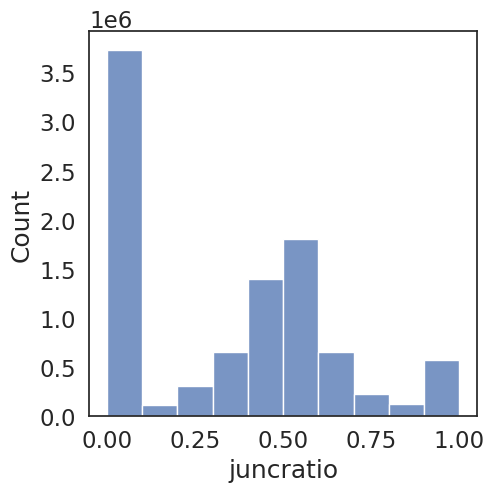

In [12]:
# set figure size to be small
plt.figure(figsize=(5,5))
sns.histplot(final_data.juncratio, bins=10)

### Let's simulate some data!

In [13]:
# update junc_info to only include junctions in clusters_SS
junc_info = junc_info[junc_info["Cluster"].isin(clusters_SS)]
junc_info = junc_info.reset_index(drop=True)
junc_info["new_junction_id_index"] = junc_info.index
junc_info.head()

,junction_id,Cluster,junction_id_index,chr,start,end,new_junction_id_index
0,1_78692220_78694195,114,12,1,78692220,78694195,0
1,1_78694346_78696080,114,13,1,78694346,78696080,1
2,1_74236899_74246079,344,20,1,74236899,74246079,2
3,1_74246114_74248131,344,21,1,74246114,74248131,3
4,1_74255014_74255957,347,22,1,74255014,74255957,4


In [18]:
cell_ids_conversion.cell_type.value_counts()

Mammary_Gland_basal_cell                                  1340
Mammary_Gland_luminal_epithelial_cell_of_mammary_gland     578
Mammary_Gland_stromal_cell                                 440
Mammary_Gland_endothelial_cell                              47
Name: cell_type, dtype: int64

In [23]:
simulated_counts, cell_types, cell_type_psi, cluster_labels = sim.simulate_junc_counts(cluster_counts_sub, junc_info, cell_types=cell_ids_conversion.cell_type.astype('category'))

Using pre-defined cell types!
The number of cell types is: 4
The number of cells is: 2405
The number of junctions is: 19164


100%|██████████| 6388/6388 [00:18<00:00, 343.28it/s]


The columns to keep are: Index([0, 1, 2, 3], dtype='object')
Done simulating PSI!
Done simulating junc counts!


In [41]:
# save simulated counts, cell types and psi values
sim_juncs_counts = simulated_counts
cell_type_psi_df = cluster_labels
# get variance in simulated psi values across all simulated cell types 
K = len(cell_types)
cell_type_psi_df["difference"] = np.mean(cell_type_psi_df[0:K])
cell_type_psi_df.head()

/gpfs/commons/home/kisaev/miniconda3/envs/leafcutter-sc/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/gpfs/commons/home/kisaev/miniconda3/envs/leafcutter-sc/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3430: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)


,0,1,2,3,new_junction_id_index,sample_label,Cluster,difference,true_label
0,0.384866,0.004640,0.494171,0.200352,0,positive,114,0.255717,negative
2,0.384866,0.004640,0.494171,0.200352,1,positive,114,0.256617,negative
0,0.025109,0.463269,0.002160,0.499967,2,positive,344,0.255717,negative
2,0.025109,0.463269,0.002160,0.499967,3,positive,344,0.256617,negative
0,0.181821,0.376602,0.447159,0.278265,4,positive,347,0.255717,negative


In [42]:
# label anything with absolute difference of 0.2 or less as not cell state associated 
cell_type_psi_df["true_label"] = np.where(abs(cell_type_psi_df["difference"]) >= 0.2, "positive", "negative")
cell_type_psi_df.sort_values(by = ["new_junction_id_index"], inplace = True)
cell_type_psi_df.true_label.value_counts()

positive    19164
Name: true_label, dtype: int64

In [43]:
# make dataframe using the following columsn 
sim_junc_counts_flat = pd.DataFrame({"cell_id_index": sim_juncs_counts.row, "new_junction_id_index": sim_juncs_counts.col, "new_junc_count": sim_juncs_counts.data})
sim_junc_counts_flat.head()

# also add new cell type column 
sim_junc_counts_flat["new_cell_type"] = np.array(cell_types[sim_junc_counts_flat["cell_id_index"]])
sim_junc_counts_flat.head()

,cell_id_index,new_junction_id_index,new_junc_count,new_cell_type
0,0,0,11.0,0
1,0,1,9.0,0
2,0,2,0.0,0
3,0,3,0.0,0
4,0,4,9.0,0


In [44]:
# update junction counts in final_data object to be the simulated counts 
final_data = final_data.merge(sim_junc_counts_flat, on = ["cell_id_index", "new_junction_id_index"])
final_data.head()

,cell_id_index,junction_id_index,junc_count,cluster_count,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,gene_id_x,gene_id_y,new_junction_id_index,new_junc_count,new_cell_type
0,0,12,19.0,24,5.0,0.791667,A1-B000167-3_56_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,11.0,0
1,1713,12,1.0,2,1.0,0.500000,L21-B002436-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,2.0,0
2,1718,12,3.0,5,2.0,0.600000,L22-B002309-3_57_F-1-1_Mammary_Gland_stromal_cell,Mammary_Gland_stromal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,0.0,3
3,1721,12,12.0,21,9.0,0.571429,L22-B002435-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,8.0,0
4,1722,12,36.0,52,16.0,0.692308,L22-B002436-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,22.0,0


In [45]:
sim_data = final_data.copy() 
# drop the old junction counts and junction id index
sim_data.drop(columns = ["junc_count", "junction_id_index"], inplace = True)
# rename columns new_junction_id_index and new_junc_count to junction_id_index and junc_count
sim_data.rename(columns = {"new_junction_id_index": "junction_id_index", "new_junc_count": "junc_count"}, inplace = True)
sim_data.head()

,cell_id_index,cluster_count,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,gene_id_x,gene_id_y,junction_id_index,junc_count,new_cell_type
0,0,24,5.0,0.791667,A1-B000167-3_56_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,11.0,0
1,1713,2,1.0,0.500000,L21-B002436-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,2.0,0
2,1718,5,2.0,0.600000,L22-B002309-3_57_F-1-1_Mammary_Gland_stromal_cell,Mammary_Gland_stromal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,0.0,3
3,1721,21,9.0,0.571429,L22-B002435-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,8.0,0
4,1722,52,16.0,0.692308,L22-B002436-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,22.0,0


In [46]:
# update cluster_count to be the sum of junction_id_index in each Cluster for each cell
new_clust_counts = sim_data.groupby(["cell_id_index", "Cluster"]).agg({"junc_count": "sum"}).reset_index()
# update column to be cluster_count 
new_clust_counts.rename(columns = {"junc_count": "cluster_count"}, inplace = True)
sim_data.drop(columns = ["cluster_count"], inplace = True)
# merge new_clust_counts with sim_data
sim_data = sim_data.merge(new_clust_counts, on = ["cell_id_index", "Cluster"])

<Axes: xlabel='junc_ratio', ylabel='Count'>

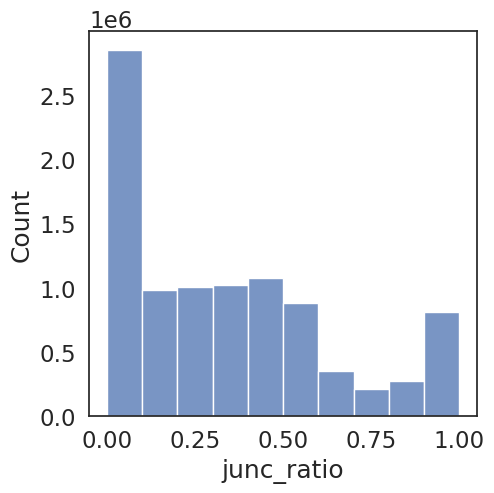

In [47]:
# update juncratio 
sim_data["clustminjunc"] = sim_data["cluster_count"] - sim_data["junc_count"]
sim_data["junc_ratio"] = sim_data["junc_count"] / sim_data["cluster_count"]

# make histogram of junc_ratio
plt.figure(figsize=(5,5))
sns.histplot(sim_data.junc_ratio, bins=10)

### Prep data for model 

In [48]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

In [49]:
cell_index_tensor, junc_index_tensor, my_data = llc.make_torch_data(sim_data, **float_type)

The number of cells going into training data is:
2405
2405


/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/Leaflet_load_cluster_data_03.py:45: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ycount_lookup = torch.sparse_coo_tensor(


In [50]:
clust_labels_only = cluster_labels[["Cluster", "sample_label"]].drop_duplicates()
simple_data = sim_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "junc_ratio", "junc_count", "cluster_count"]]
# merge with clust_labels_only 
simple_data = simple_data.merge(clust_labels_only, on = ["Cluster"])
# get true PSI for each Cluster 
simple_data.head()

,cell_id_index,Cluster,cell_type,junction_id_index,junc_ratio,junc_count,cluster_count,sample_label
0,0,114,Mammary_Gland_basal_cell,0,0.458333,11.0,24.0,positive
1,0,114,Mammary_Gland_basal_cell,1,0.375000,9.0,24.0,positive
2,0,114,Mammary_Gland_basal_cell,16117,0.166667,4.0,24.0,positive
3,1713,114,Mammary_Gland_basal_cell,0,0.666667,2.0,3.0,positive
4,1713,114,Mammary_Gland_basal_cell,1,0.000000,0.0,3.0,positive


15485
Mammary_Gland_basal_cell                                  642
Mammary_Gland_luminal_epithelial_cell_of_mammary_gland    459
Mammary_Gland_stromal_cell                                324
Mammary_Gland_endothelial_cell                             42
Name: cell_type, dtype: int64


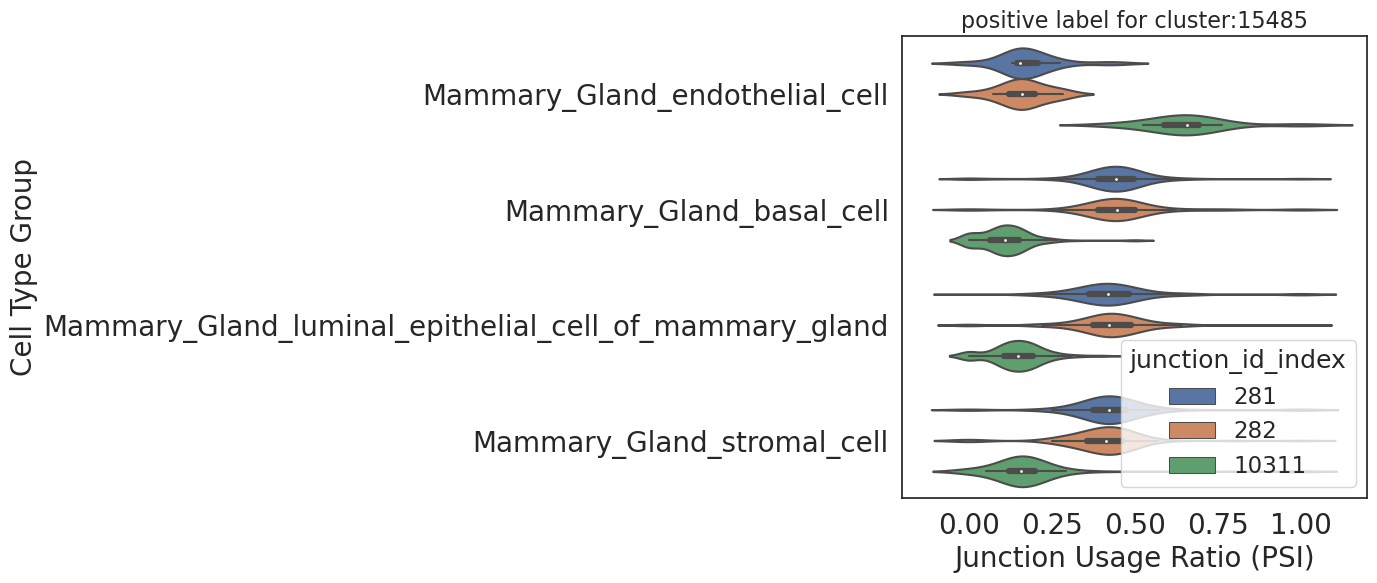

In [58]:
# let's visualize junction usage ratios for a given custer 
# sample clust from simple_data.Cluster.unique()
clust = np.random.choice(simple_data.Cluster.unique())
print(clust)
sim.quick_clust_plot(clust, simple_data)

In [59]:
indices = torch.tensor(sim_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(sim_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = sim_data['cell_id_index'].max() + 1
num_junctions = sim_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [60]:
indices_counts = torch.tensor(sim_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(sim_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = sim_data['cell_id_index'].max() + 1
num_junctions_counts = sim_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [61]:
# save full dataset y_tensor and total_counts_tensor 
full_y_tensor = y_tensor
full_total_counts_tensor = total_counts_tensor

### Run full model

2.1.0.dev20230321+cu117
11.7
Tesla V100-PCIE-16GB
Using prior for a and b per junction to model average behaviour!
Initialization 1 with seed 2248
Define the guide
Fit the model
Epoch 0, Loss: 204633747.6721141
Epoch 20, Loss: 60968029.889916345
Epoch 40, Loss: 30021217.991147693
Epoch 60, Loss: 22939148.566609807
Epoch 80, Loss: 20487425.74823188
Epoch 100, Loss: 19058097.99286291
Epoch 120, Loss: 18232004.638422832
Epoch 140, Loss: 17650560.434007343
Epoch 160, Loss: 17302478.719525173
Epoch 180, Loss: 17063480.034324404
Epoch 200, Loss: 16901776.060908776
Epoch 220, Loss: 16805874.667007636
Epoch 240, Loss: 16732390.630997553
Epoch 260, Loss: 16678755.199248513
Epoch 280, Loss: 16640684.650812492
Epoch 300, Loss: 16608468.142828304
Epoch 320, Loss: 16582330.144686049
Epoch 340, Loss: 16556733.879094455
Epoch 360, Loss: 16538519.618766194
Epoch 380, Loss: 16522277.477362651
Epoch 400, Loss: 16505753.012067173
Epoch 420, Loss: 16493098.70980379
Epoch 440, Loss: 16480089.074498067
Epoc

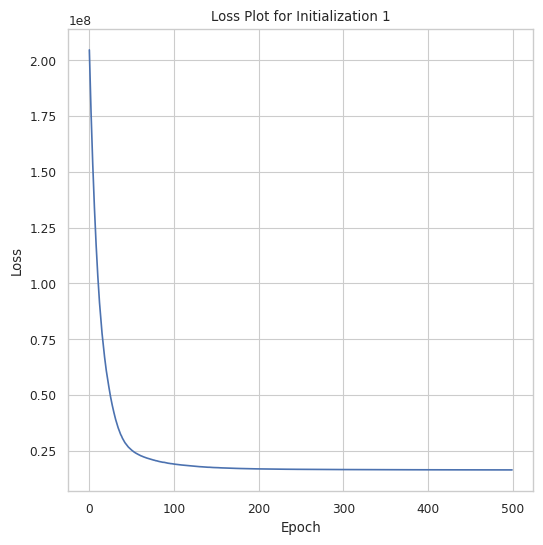

Sample from the guide (posterior)
Extract the latent variables
Initialization 2 with seed 8821
Define the guide
Fit the model
Epoch 0, Loss: 200257742.4229082
Epoch 20, Loss: 59814242.47332232
Epoch 40, Loss: 30830138.888495296
Epoch 60, Loss: 24043181.84779255
Epoch 80, Loss: 21006743.094830915
Epoch 100, Loss: 18788469.449066997
Epoch 120, Loss: 17602160.97130622
Epoch 140, Loss: 17148523.003365684
Epoch 160, Loss: 16938228.770938396
Epoch 180, Loss: 16822596.582621016
Epoch 200, Loss: 16746254.957986575
Epoch 220, Loss: 16686521.732381865
Epoch 240, Loss: 16640371.292390559
Epoch 260, Loss: 16599045.744380258
Epoch 280, Loss: 16567648.287321515
Epoch 300, Loss: 16537977.996297058
Epoch 320, Loss: 16515676.468802148
Epoch 340, Loss: 16495443.260774251
Epoch 360, Loss: 16477261.514219817
Epoch 380, Loss: 16462810.171992663
Epoch 400, Loss: 16446429.470280606
Epoch 420, Loss: 16434474.886884484
Epoch 440, Loss: 16422499.042432431
Epoch 460, Loss: 16411339.275853882
Epoch 480, Loss: 164

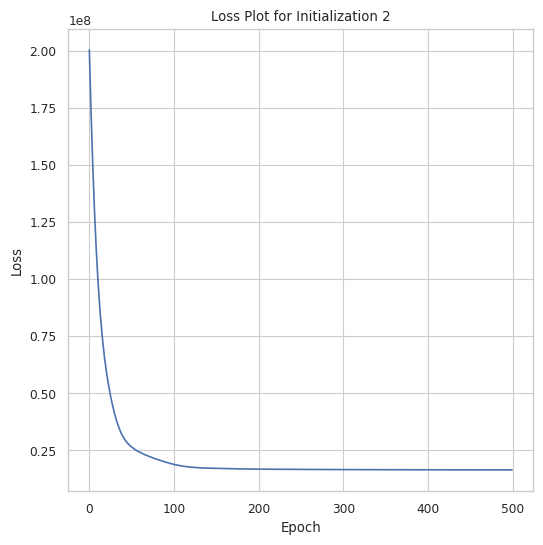

Sample from the guide (posterior)
Extract the latent variables
Initialization 3 with seed 6128
Define the guide
Fit the model
Epoch 0, Loss: 194878653.78421527
Epoch 20, Loss: 57589896.533591405
Epoch 40, Loss: 29369198.541206814
Epoch 60, Loss: 23210590.30989921
Epoch 80, Loss: 19226445.206475817
Epoch 100, Loss: 17641475.805500116
Epoch 120, Loss: 17143014.836969446
Epoch 140, Loss: 16931419.88436326
Epoch 160, Loss: 16816791.954750925
Epoch 180, Loss: 16742478.414528932
Epoch 200, Loss: 16688504.544066504
Epoch 220, Loss: 16654279.27176337
Epoch 240, Loss: 16626040.332401332
Epoch 260, Loss: 16604237.438755445
Epoch 280, Loss: 16587594.580598338
Epoch 300, Loss: 16573415.66846827
Epoch 320, Loss: 16562475.68105767
Epoch 340, Loss: 16553594.553334586
Epoch 360, Loss: 16545744.530830292
Epoch 380, Loss: 16539248.681855971
Epoch 400, Loss: 16533108.842565171
Epoch 420, Loss: 16528859.968613038
Epoch 440, Loss: 16524895.448394082
Epoch 460, Loss: 16520474.62372936
Epoch 480, Loss: 16518

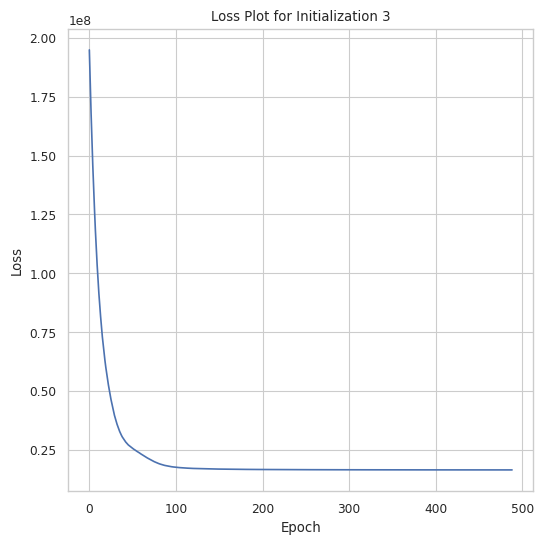

Sample from the guide (posterior)
Extract the latent variables
Initialization 4 with seed 6253
Define the guide
Fit the model
Epoch 0, Loss: 196025161.229068
Epoch 20, Loss: 59060077.533742175
Epoch 40, Loss: 29151905.81608995
Epoch 60, Loss: 19926298.327226564
Epoch 80, Loss: 17834101.522456642
Epoch 100, Loss: 17251770.258471165
Epoch 120, Loss: 17007857.106407158
Epoch 140, Loss: 16872888.51517559
Epoch 160, Loss: 16789253.407451693
Epoch 180, Loss: 16728655.61657667
Epoch 200, Loss: 16685700.48948754
Epoch 220, Loss: 16650631.498131445
Epoch 240, Loss: 16626274.729133543
Epoch 260, Loss: 16604160.255394299
Epoch 280, Loss: 16589079.143980004
Epoch 300, Loss: 16574473.720940985
Epoch 320, Loss: 16563344.675230416
Epoch 340, Loss: 16554018.949745504
Epoch 360, Loss: 16547955.785127094
Epoch 380, Loss: 16540879.996521194
Epoch 400, Loss: 16533862.890904758
Epoch 420, Loss: 16528834.383603107
Stopping early at epoch 438. Best Loss: 16525473.308237853


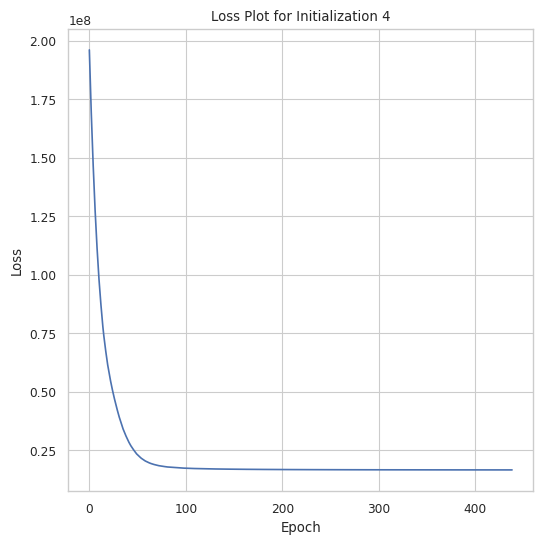

Sample from the guide (posterior)
Extract the latent variables
Initialization 5 with seed 2806
Define the guide
Fit the model
Epoch 0, Loss: 195989161.83294785
Epoch 20, Loss: 58622214.69390164
Epoch 40, Loss: 29979065.208196342
Epoch 60, Loss: 23973484.507939756
Epoch 80, Loss: 21975459.564895578
Epoch 100, Loss: 20652776.02426537
Epoch 120, Loss: 19554878.586535912
Epoch 140, Loss: 18738088.45196136
Epoch 160, Loss: 18088929.67979344
Epoch 180, Loss: 17547911.967689566
Epoch 200, Loss: 17173492.19128204
Epoch 220, Loss: 16949050.53309322
Epoch 240, Loss: 16818634.0915421
Epoch 260, Loss: 16730033.266534327
Epoch 280, Loss: 16664703.13974576
Epoch 300, Loss: 16620446.606582776
Epoch 320, Loss: 16585431.957264084
Epoch 340, Loss: 16556555.7147298
Epoch 360, Loss: 16531297.443782486
Epoch 380, Loss: 16507103.360896321
Epoch 400, Loss: 16486671.047240645
Epoch 420, Loss: 16470896.148342945
Epoch 440, Loss: 16452381.759455074
Epoch 460, Loss: 16436083.568465766
Epoch 480, Loss: 16421432.7

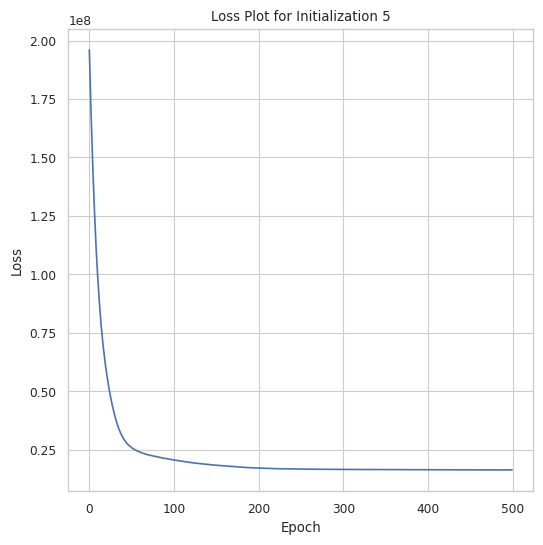

Sample from the guide (posterior)
Extract the latent variables
Initialization 6 with seed 6269
Define the guide
Fit the model
Epoch 0, Loss: 200824393.7434326
Epoch 20, Loss: 58909923.60093442
Epoch 40, Loss: 26684397.032566465
Epoch 60, Loss: 19280492.41606258
Epoch 80, Loss: 17742179.528010603
Epoch 100, Loss: 17250481.820227854
Epoch 120, Loss: 17008895.70739773
Epoch 140, Loss: 16856987.637225494
Epoch 160, Loss: 16739853.457414845
Epoch 180, Loss: 16641204.757620335
Epoch 200, Loss: 16557057.266877024
Epoch 220, Loss: 16481298.667979948
Epoch 240, Loss: 16410429.634024234
Epoch 260, Loss: 16355429.602797318
Epoch 280, Loss: 16310461.443199432
Epoch 300, Loss: 16269061.634466037
Epoch 320, Loss: 16236637.612344474
Epoch 340, Loss: 16206264.648113409
Epoch 360, Loss: 16180664.556281868
Epoch 380, Loss: 16158843.043847932
Epoch 400, Loss: 16140771.913143292
Epoch 420, Loss: 16121612.244453222
Epoch 440, Loss: 16103568.4616743
Epoch 460, Loss: 16089080.93168268
Epoch 480, Loss: 160742

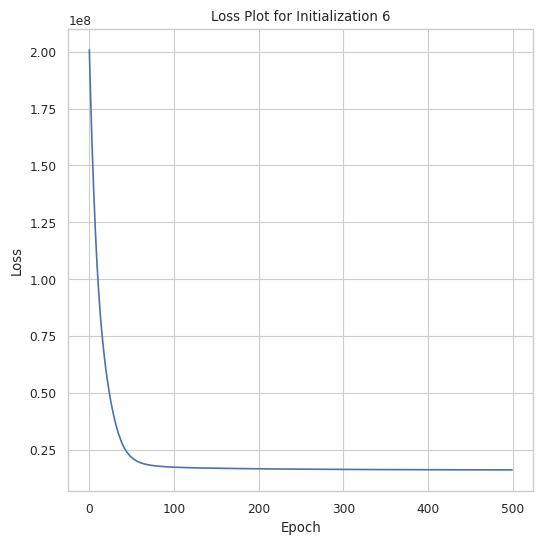

Sample from the guide (posterior)
Extract the latent variables
Initialization 7 with seed 8052
Define the guide
Fit the model
Epoch 0, Loss: 201541728.73766255
Epoch 20, Loss: 60554599.10422163
Epoch 40, Loss: 29109549.627244756
Epoch 60, Loss: 21320108.857468538
Epoch 80, Loss: 18830054.98438528
Epoch 100, Loss: 17851789.827231932
Epoch 120, Loss: 17359970.316504
Epoch 140, Loss: 17102075.538467605
Epoch 160, Loss: 16946460.987575103
Epoch 180, Loss: 16836545.558585163
Epoch 200, Loss: 16758691.046557669
Epoch 220, Loss: 16692916.48636274
Epoch 240, Loss: 16625029.74080377
Epoch 260, Loss: 16571270.414637882
Epoch 280, Loss: 16521030.151556741
Epoch 300, Loss: 16477353.35513005
Epoch 320, Loss: 16435304.404262789
Epoch 340, Loss: 16398916.474428182
Epoch 360, Loss: 16364474.427995162
Epoch 380, Loss: 16332800.620448237
Epoch 400, Loss: 16305403.287080582
Epoch 420, Loss: 16278253.86804837
Epoch 440, Loss: 16254076.465771891
Epoch 460, Loss: 16232915.862591771
Epoch 480, Loss: 16214061

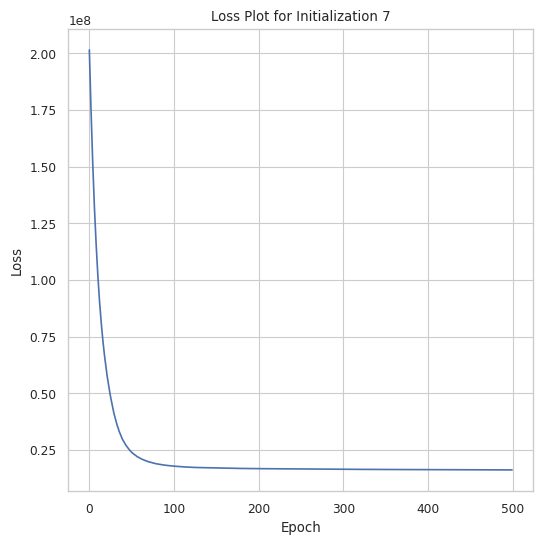

Sample from the guide (posterior)
Extract the latent variables
Initialization 8 with seed 9632
Define the guide
Fit the model
Epoch 0, Loss: 205992139.6536663
Epoch 20, Loss: 62069723.60377424
Epoch 40, Loss: 29989631.389260493
Epoch 60, Loss: 21767920.614722278
Epoch 80, Loss: 18958693.464622755
Epoch 100, Loss: 17760782.114699688
Epoch 120, Loss: 17299427.042483404
Epoch 140, Loss: 17038493.741320238
Epoch 160, Loss: 16894294.858720943
Epoch 180, Loss: 16801911.204607062
Epoch 200, Loss: 16734163.702857919
Epoch 220, Loss: 16686251.829908758
Epoch 240, Loss: 16648704.063521737
Epoch 260, Loss: 16618630.821267962
Epoch 280, Loss: 16591636.617168419
Epoch 300, Loss: 16567719.379075088
Epoch 320, Loss: 16548610.605514899
Epoch 340, Loss: 16528798.603769153
Epoch 360, Loss: 16513531.987076158
Epoch 380, Loss: 16497075.911578733
Epoch 400, Loss: 16480594.627685748
Epoch 420, Loss: 16466680.289928364
Epoch 440, Loss: 16454208.5794418
Epoch 460, Loss: 16441828.358241957
Epoch 480, Loss: 164

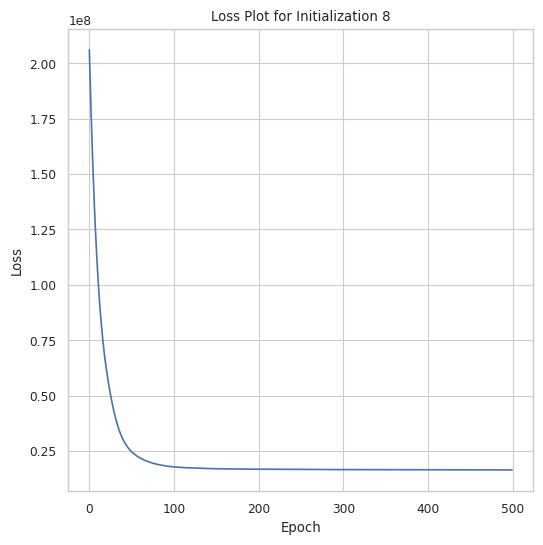

Sample from the guide (posterior)
Extract the latent variables
Initialization 9 with seed 740
Define the guide
Fit the model
Epoch 0, Loss: 204844966.75914997
Epoch 20, Loss: 62177065.96827343
Epoch 40, Loss: 28178330.365010004
Epoch 60, Loss: 19473642.884295925
Epoch 80, Loss: 17781810.682149876
Epoch 100, Loss: 17241889.37811015
Epoch 120, Loss: 16959915.125308514
Epoch 140, Loss: 16743886.488243993
Epoch 160, Loss: 16574199.736328501
Epoch 180, Loss: 16442363.548523016
Epoch 200, Loss: 16339305.840456499
Epoch 220, Loss: 16267157.272061694
Epoch 240, Loss: 16211478.615623714
Epoch 260, Loss: 16169469.825251691
Epoch 280, Loss: 16136605.672862172
Epoch 300, Loss: 16112225.791942406
Epoch 320, Loss: 16095059.908260312
Epoch 340, Loss: 16080475.261328962
Epoch 360, Loss: 16067496.707934774
Epoch 380, Loss: 16057009.493680988
Epoch 400, Loss: 16048647.658059034
Epoch 420, Loss: 16041484.565734092
Epoch 440, Loss: 16034875.45828313
Epoch 460, Loss: 16030260.599079818
Epoch 480, Loss: 160

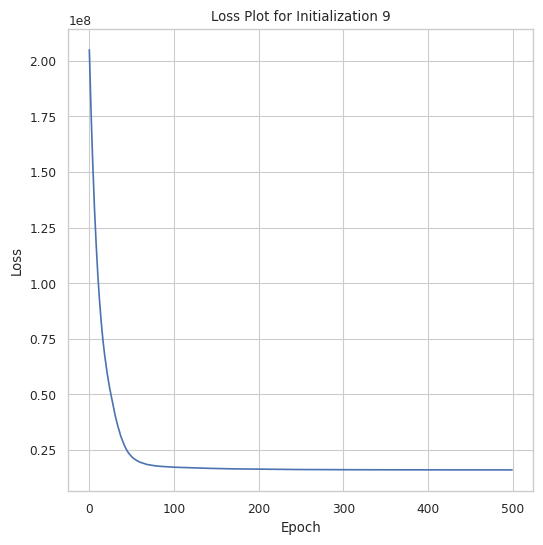

Sample from the guide (posterior)
Extract the latent variables
Initialization 10 with seed 8316
Define the guide
Fit the model
Epoch 0, Loss: 205252831.11094886
Epoch 20, Loss: 60906736.4707035
Epoch 40, Loss: 28205485.471406635
Epoch 60, Loss: 20648834.56677756
Epoch 80, Loss: 18504886.006855026
Epoch 100, Loss: 17645229.338079676
Epoch 120, Loss: 17248678.013590634
Epoch 140, Loss: 17038202.169949703
Epoch 160, Loss: 16904069.025100127
Epoch 180, Loss: 16819358.095084377
Epoch 200, Loss: 16747487.317967337
Epoch 220, Loss: 16691776.062138896
Epoch 240, Loss: 16644374.148102116
Epoch 260, Loss: 16598846.095345087
Epoch 280, Loss: 16560081.468115944
Epoch 300, Loss: 16525698.834163737
Epoch 320, Loss: 16494511.624977361
Epoch 340, Loss: 16464947.255797453
Epoch 360, Loss: 16436874.386686482
Epoch 380, Loss: 16407620.443407182
Epoch 400, Loss: 16380661.640332244
Epoch 420, Loss: 16354900.034510368
Epoch 440, Loss: 16325902.26160452
Epoch 460, Loss: 16299758.014624622
Epoch 480, Loss: 16

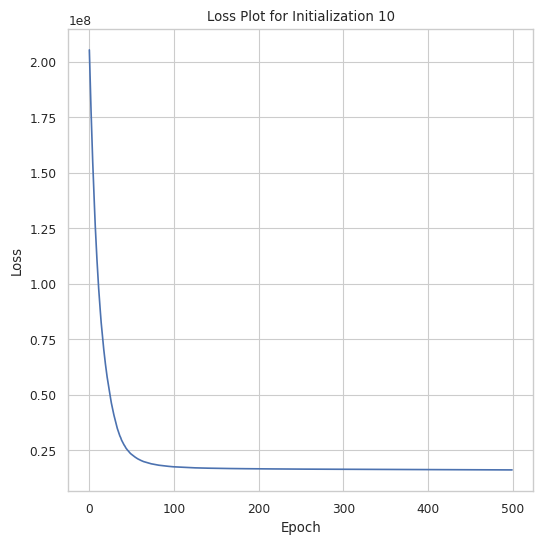

Sample from the guide (posterior)
Extract the latent variables
All initializations complete. Returning results.
------------------------------------------------


In [99]:
reload(factor_model)
best_K = 4 
K = best_K

all_results = factor_model.main(full_y_tensor, full_total_counts_tensor, num_initializations=10, use_global_prior=True, K=K, lr=0.1, loss_plot=True, num_epochs=500, save_to_file = False)

In [100]:
# extract latent variables for all iterations 
latent_results = {} 
for i in range(len(all_results)):
    latent_vars = all_results[i]['latent_vars']
    pi = latent_vars["pi"] # overall contribution of each factor to cell population, one value per k
    conc = latent_vars["conc"] # one scaling value 
    assign_post = latent_vars["assign"]
    psis = latent_vars["psi"] # psi is the probability of a junction being used in a cluster
    a = latent_vars["a"] 
    b = latent_vars["b"] 
    print("The inferred concentration parameter is: " + str(conc))
    print("The inferred pi parameter is: " + str(pi))
    # add all latent variables to latent_results dictionary
    latent_results[i] = {"pi": pi, "conc": conc, "assign_post": assign_post, "psis": psis, "a": a, "b": b}

The inferred concentration parameter is: 0.5740645
The inferred pi parameter is: [0.37413046 0.23390669 0.19025476 0.20170806]
The inferred concentration parameter is: 0.625792
The inferred pi parameter is: [0.25744566 0.3019716  0.25731596 0.18326673]
The inferred concentration parameter is: 0.59239227
The inferred pi parameter is: [0.23500082 0.27684265 0.30426446 0.18389203]
The inferred concentration parameter is: 0.61943066
The inferred pi parameter is: [0.402741   0.22792394 0.1794737  0.18986139]
The inferred concentration parameter is: 0.7298573
The inferred pi parameter is: [0.23685071 0.18226938 0.30371132 0.27716854]
The inferred concentration parameter is: 0.5419559
The inferred pi parameter is: [0.37843794 0.23575822 0.19307247 0.19273141]
The inferred concentration parameter is: 0.59985423
The inferred pi parameter is: [0.37681976 0.24173428 0.21202298 0.169423  ]
The inferred concentration parameter is: 0.73703253
The inferred pi parameter is: [0.22042301 0.19061238 0.31

In [101]:
cell_types_id = sim_data[["cell_id", "cell_id_index", "new_cell_type"]].drop_duplicates()
# reorder by cell_id_index
cell_types_id = cell_types_id.sort_values(by = ["cell_id_index"])
cell_types_id.head()

,cell_id,cell_id_index,new_cell_type
0,A1-B000167-3_56_F-1-1_Mammary_Gland_basal_cell,0,0
6429,A10-B000166-3_56_F-1-1_Mammary_Gland_basal_cell,1,0
1677,A10-B002433-3_38_F-1-1_Mammary_Gland_basal_cell,2,0
1473,A10-B002435-3_39_F-1-1_Mammary_Gland_basal_cell,3,0
6420,A10-B002436-3_39_F-1-1_Mammary_Gland_basal_cell,4,0


In [102]:
cell_types_id.new_cell_type.value_counts()

0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64

In [104]:
# from dictionary of latent variables, get the assign_post for each iteration and add to a dataframe
assign_post = []
for i in range(len(latent_results)):
    assign_post_df = pd.DataFrame(latent_results[i]["assign_post"])
    assign_post_df["new_cell_type"] = cell_types_id.new_cell_type.values
    print(assign_post_df.new_cell_type.value_counts())
    assign_post.append(latent_results[i]["assign_post"])

0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64
0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64
0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64
0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64
0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64
0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64
0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64
0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64
0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64
0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64


### Evaluate latent factor space

In [110]:
import seaborn as sns

color_palette = sns.color_palette("Set1", n_colors=len(cell_types_id['new_cell_type'].unique()))
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_types_id['new_cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_types = cell_types_id.new_cell_type.values

# create colours for each cell type 
cell_type_colors = {new_cell_type: color for new_cell_type, color in zip(unique_cell_types, colors)}
row_colors = [cell_type_colors[new_cell_type] for new_cell_type in cell_types]

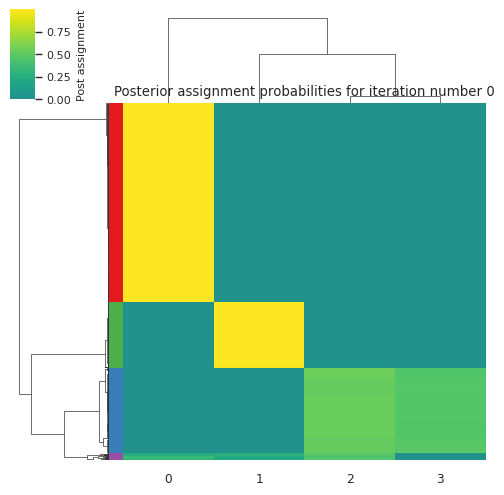

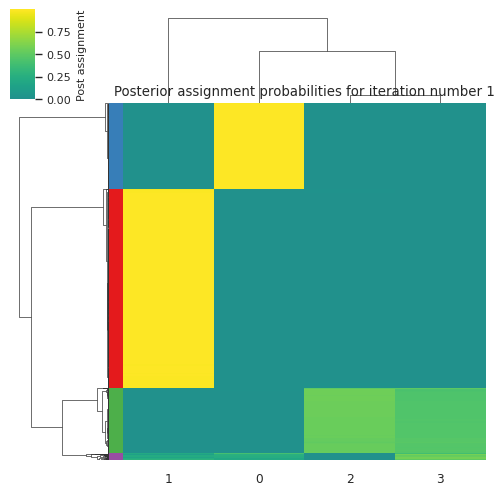

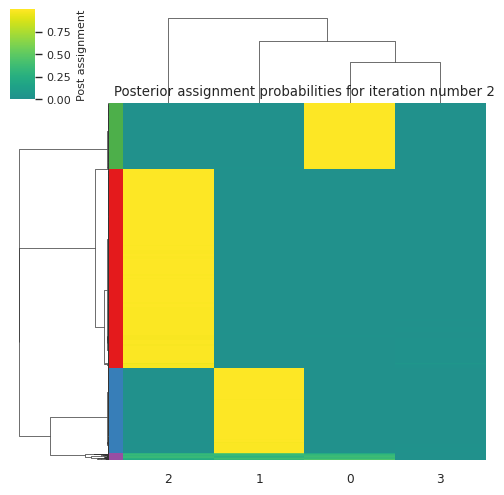

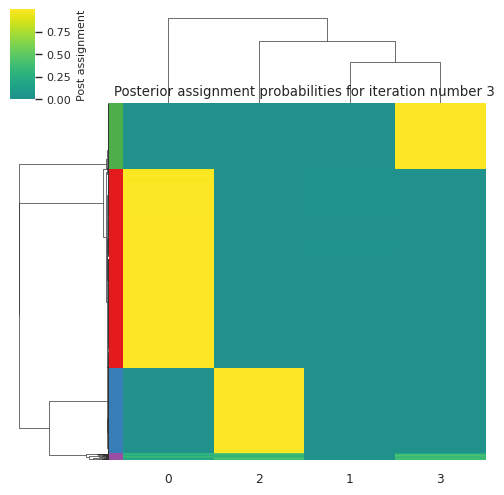

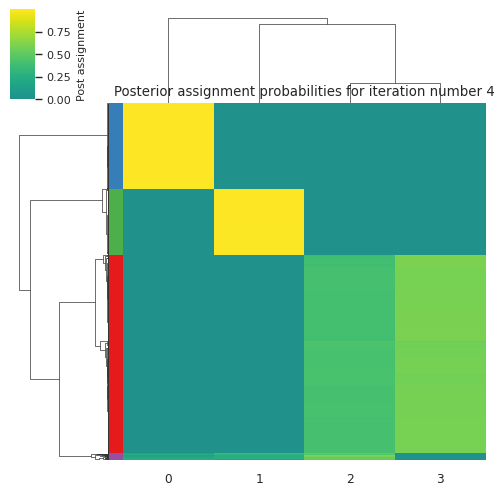

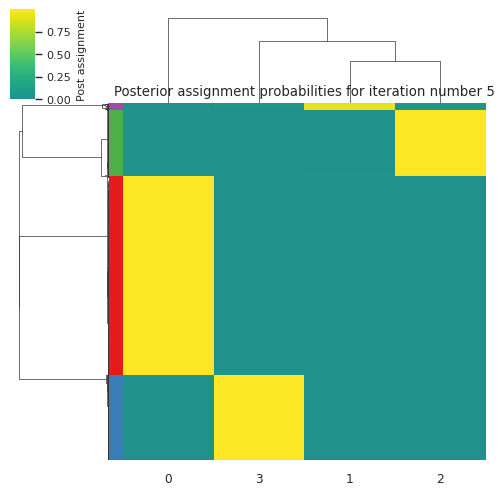

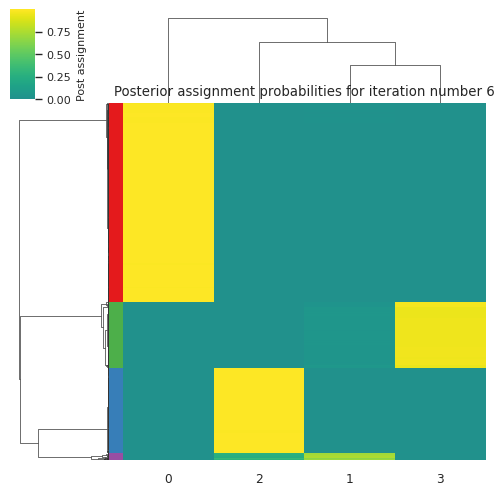

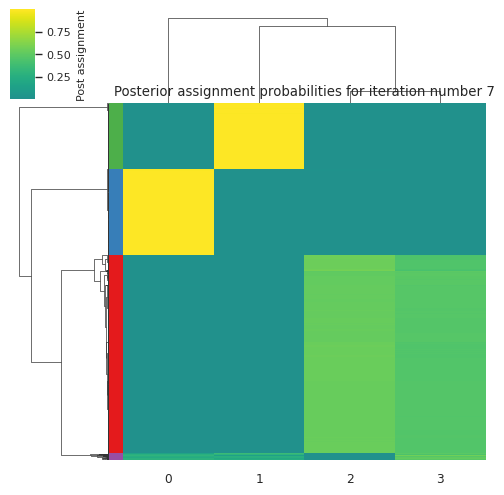

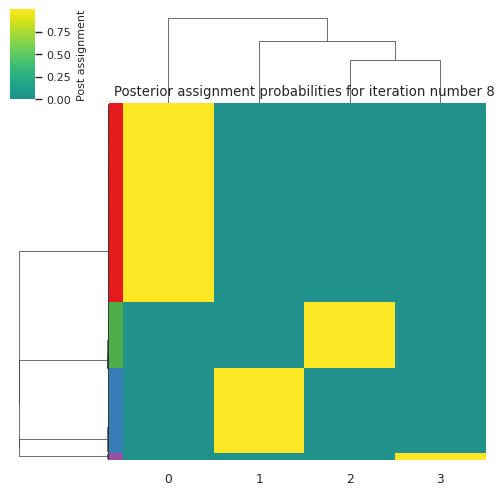

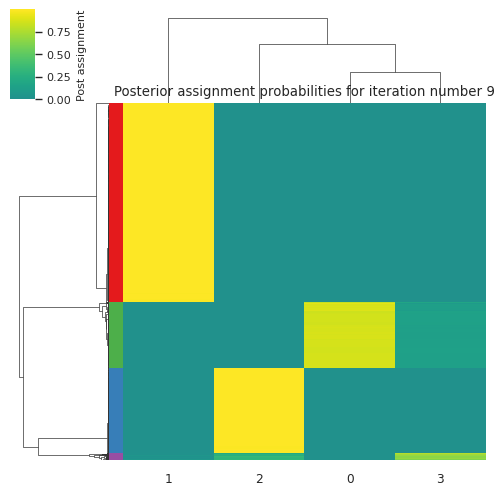

In [111]:
for i in range(len(assign_post)):
    cluster = sns.clustermap(
        data=assign_post[i],
        method='complete',
        cmap="viridis",
        annot=False,
        fmt=".2f",
        yticklabels=False,
        figsize=(5, 5),
        center=0,
        row_colors=row_colors,  # Apply row colors
        cbar_kws={'label': 'Post assignment'} 
        )
    cluster.cax.set_ylabel('Post assignment', size=8)
    # add title 
    cluster.ax_heatmap.set_title('Posterior assignment probabilities for iteration number ' + str(i))
    # Increase font size for color bar tick labels:
    cbar_ax = cluster.cax
    for label in cbar_ax.yaxis.get_ticklabels():
        label.set_size(8)

In [113]:
umaps = []

for i in range(len(assign_post)):
    print("Running UMAP for iteration number " + str(i))
    # make UMAP using average assign_post across seeds and color points by cell_type 
    reducer = umap.UMAP(n_components=10, random_state=42)
    embedding = reducer.fit_transform(assign_post[i])
    umaps.append(embedding)

Running UMAP for iteration number 0
Running UMAP for iteration number 1
Running UMAP for iteration number 2
Running UMAP for iteration number 3
Running UMAP for iteration number 4
Running UMAP for iteration number 5
Running UMAP for iteration number 6
Running UMAP for iteration number 7
Running UMAP for iteration number 8
Running UMAP for iteration number 9


In [119]:
# make function for plotting UMAPs 
def umap_plot(umap, cell_type_colors, cell_types):
    sns.set_style("whitegrid")
    sns.set_context("paper")
    plt.figure(figsize=(4, 4))    
    plt.scatter(umap[:, 0], umap[:, 1],
        c=[cell_type_colors[cell_type] for cell_type in cell_types],
        s=8, alpha=0.4)
    # xlab 
    plt.xlabel("UMAP 1")
    # ylab
    plt.ylabel("UMAP 2")

Plotting UMAP for iteration number 0
Plotting UMAP for iteration number 1
Plotting UMAP for iteration number 2
Plotting UMAP for iteration number 3
Plotting UMAP for iteration number 4
Plotting UMAP for iteration number 5
Plotting UMAP for iteration number 6
Plotting UMAP for iteration number 7
Plotting UMAP for iteration number 8
Plotting UMAP for iteration number 9


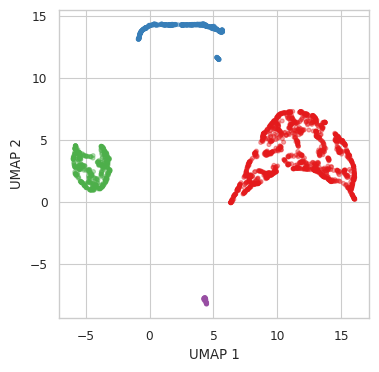

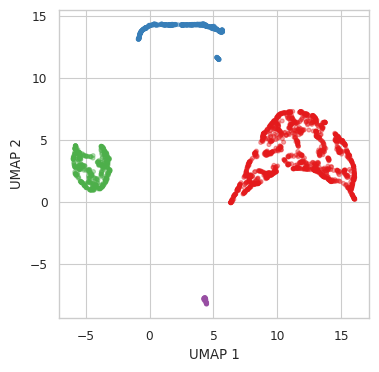

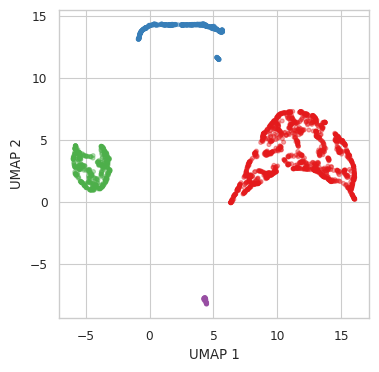

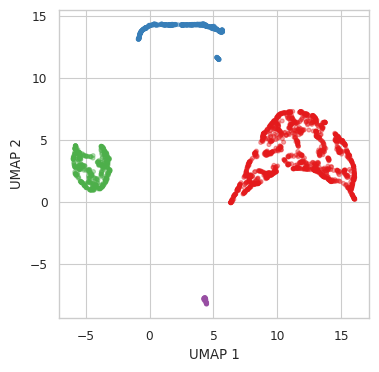

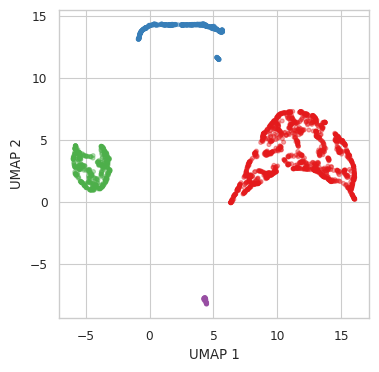

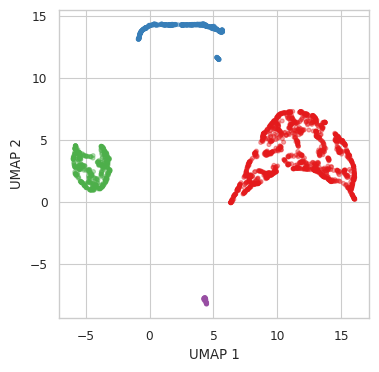

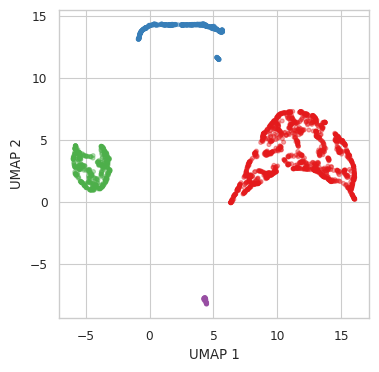

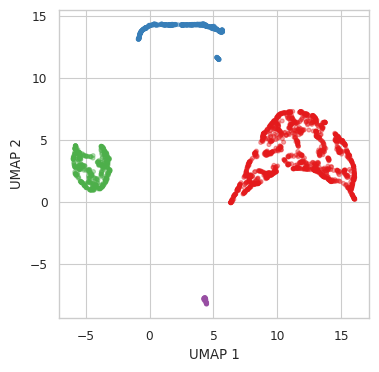

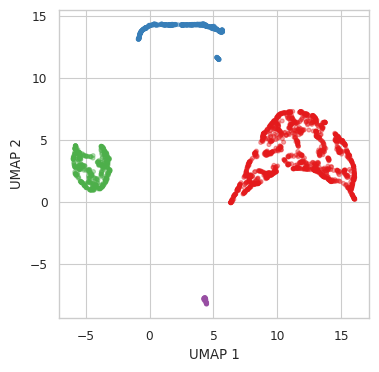

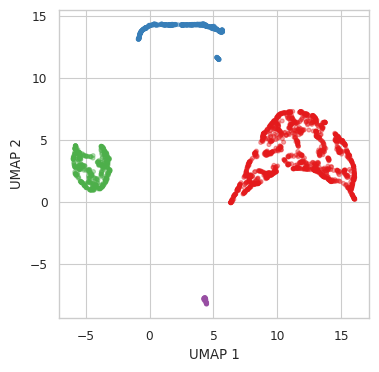

In [121]:
for i in range(len(umaps)):
    print("Plotting UMAP for iteration number " + str(i))
    umap_plot(umaps[i], cell_type_colors, cell_types)